# N16 — Undercut Success Predictor

An undercut is one of the most decisive tactical moves in F1: pitting before a rival to gain track position through fresher tyre pace. But it only works if the time lost in the pit lane (pit delta) is smaller than the gap you need to bridge. This notebook builds a binary classifier that predicts whether a given undercut attempt will succeed — defined as driver X gaining net position over rival Y after both complete their pit sequences.

## What is an undercut?

Driver X is behind driver Y by gap G. X pits first. Y stays out for ≤ 5 laps, then also pits.
After both are on new tyres and the pit sequence is complete, if X is ahead of Y: **undercut successful**.

The outcome depends on three competing forces:
- **Pit delta**: time lost by X entering the pit lane (inlap + outlap vs. two normal laps). If pit_delta > G, X exits behind Y even with fresher tyres.
- **Fresh tyre pace gain**: X's new tyres are faster than Y's worn ones. Each lap Y stays out, X closes the gap.
- **Track position value**: at circuits where overtaking is hard, even a small position gain is decisive.

## Modeling approach

Binary LightGBM classifier (same architecture as N12/N14). Target: `undercut_success = 1` if X
gains position over Y after the pit sequence. Labels constructed from FastF1 race data (2023–2025)
by detecting pit sequences where one driver pits within 5 laps of the other.

The `pit_delta` feature is derived analytically:


---

## Step 0: Setup and Data Labeling

### Imports and dir setup

In [ ]:
# ── Step 0 · Setup + undercut pair labeling ────────────────────────────────
import sys
from pathlib import Path
repo_root = Path.cwd()
while not (repo_root / ".git").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import fastf1
import warnings
warnings.filterwarnings("ignore")

CACHE_DIR  = repo_root / "data" / "cache" / "fastf1"
EXPORT_DIR = repo_root / "data" / "models" / "pit_prediction"
PROC_DIR   = repo_root / "data" / "processed" / "undercut_labeled"
OUTPUTS    = repo_root / "notebooks" / "strategy" / "pit_prediction" / "outputs"

for d in [CACHE_DIR, EXPORT_DIR, PROC_DIR, OUTPUTS]:
    d.mkdir(parents=True, exist_ok=True)

import logging
logging.getLogger("fastf1").setLevel(logging.WARNING)
fastf1.Cache.enable_cache(str(CACHE_DIR))


### Data Labeling and computing

In [ ]:
YEARS = [2023, 2024, 2025]
# Maximum laps between X pitting and Y pitting for it to count as an undercut attempt
MAX_LAP_GAP = 5

In [ ]:
def compute_pit_delta(laps_driver, pit_lap):
    """
    pit_delta = inlap_time + outlap_time - 2 × median_race_lap
    inlap  = lap where PitInTime is set (lap N)
    outlap = lap where PitOutTime is set (lap N+1)
    median_race_lap = median of all 'normal' laps (IsAccurate=True, no pit in/out)
    """
    normal = laps_driver[
        laps_driver["IsAccurate"] &
        laps_driver["PitInTime"].isna() &
        laps_driver["PitOutTime"].isna()
    ]["LapTime"].dt.total_seconds().dropna()

    if len(normal) < 3:
        return np.nan

    median_lap = normal.median()

    inlap_row  = laps_driver[laps_driver["LapNumber"] == pit_lap]
    outlap_row = laps_driver[laps_driver["LapNumber"] == pit_lap + 1]

    if inlap_row.empty or outlap_row.empty:
        return np.nan

    inlap_t  = inlap_row["LapTime"].dt.total_seconds().values[0]
    outlap_t = outlap_row["LapTime"].dt.total_seconds().values[0]

    if pd.isna(inlap_t) or pd.isna(outlap_t):
        return np.nan

    return inlap_t + outlap_t - 2 * median_lap

In [ ]:
def _build_ts_lookup(laps):
    """Build a {lap_number: track_status} dict from session laps (race-wide signal)."""
    return laps.groupby("LapNumber")["TrackStatus"].first().to_dict()


def _has_sc_in_range(ts_lookup, lap_x, lap_y):
    """Return True if any lap in [lap_x, lap_y] has SC or VSC status."""
    sc_codes = {"4", "5", "6", "7"}
    return any(
        sc_codes & set(str(ts_lookup.get(lap, "1")))
        for lap in range(int(lap_x), int(lap_y) + 1)
    )


def _label_gp_pairs(laps, year, gp, max_lap_gap, ts_lookup):
    """Return a list of undercut pair records for a single GP session."""
    pit_laps = laps[laps["PitInTime"].notna()][
        ["Driver", "Team", "LapNumber", "Compound", "TyreLife", "PitInTime", "Position"]
    ].copy()

    records = []
    for drv_x in pit_laps["Driver"].unique():
        pits_x = pit_laps[pit_laps["Driver"] == drv_x]
        laps_x = laps[laps["Driver"] == drv_x]

        for _, pit_x in pits_x.iterrows():
            lap_x        = int(pit_x["LapNumber"])
            pos_x_before = pit_x["Position"]
            if pd.isna(pos_x_before):
                continue

            rivals = pit_laps[
                (pit_laps["Driver"] != drv_x) &
                (pit_laps["LapNumber"] > lap_x) &
                (pit_laps["LapNumber"] <= lap_x + max_lap_gap)
            ]

            for _, pit_y in rivals.iterrows():
                drv_y  = pit_y["Driver"]
                lap_y  = int(pit_y["LapNumber"])
                laps_y = laps[laps["Driver"] == drv_y]

                y_at_lap_x = laps_y[laps_y["LapNumber"] == lap_x]
                if y_at_lap_x.empty:
                    continue
                pos_y_at_pit_x = y_at_lap_x["Position"].values[0]
                if pd.isna(pos_y_at_pit_x) or pos_x_before <= pos_y_at_pit_x:
                    continue

                check_lap = lap_y + 3
                x_after   = laps_x[laps_x["LapNumber"] == check_lap]
                y_after   = laps_y[laps_y["LapNumber"] == check_lap]
                if x_after.empty or y_after.empty:
                    continue

                pos_x_after = x_after["Position"].values[0]
                pos_y_after = y_after["Position"].values[0]
                if pd.isna(pos_x_after) or pd.isna(pos_y_after):
                    continue

                records.append({
                    "Year":             year,
                    "GP_Name":          gp,
                    "Driver_X":         drv_x,
                    "Team_X":           pit_x["Team"],
                    "Driver_Y":         drv_y,
                    "Team_Y":           pit_y["Team"],
                    "Lap_X_pits":       lap_x,
                    "Lap_Y_pits":       lap_y,
                    "Lap_gap":          lap_y - lap_x,
                    "TyreLife_X":       pit_x["TyreLife"],
                    "TyreLife_Y":       pit_y["TyreLife"],
                    "Compound_X":       pit_x["Compound"],
                    "Compound_Y":       pit_y["Compound"],
                    "pos_X_before":     pos_x_before,
                    "pos_Y_before":     pos_y_at_pit_x,
                    "pit_delta_X":      compute_pit_delta(laps_x, lap_x),
                    "has_sc":           _has_sc_in_range(ts_lookup, lap_x, lap_y),
                    "undercut_success": int(pos_x_after < pos_y_after),
                })
    return records


def label_undercuts(years, max_lap_gap=MAX_LAP_GAP):
    """Load all race sessions and label undercut attempt pairs across seasons."""
    all_records = []

    for year in years:
        schedule = fastf1.get_event_schedule(year, include_testing=False)
        gp_names = schedule[schedule["EventFormat"] != "testing"]["EventName"].tolist()

        for gp in gp_names:
            try:
                session = fastf1.get_session(year, gp, "R")
                session.load(laps=True, telemetry=False, weather=False, messages=False)
            except Exception as e:
                print(f"  SKIP {year} {gp}: {e}")
                continue

            laps       = session.laps.copy()
            ts_lookup  = _build_ts_lookup(laps)
            gp_records = _label_gp_pairs(laps, year, gp, max_lap_gap, ts_lookup)
            all_records.extend(gp_records)
            print(f"  {year} {gp}: {len(gp_records)} pairs")

    df = pd.DataFrame(all_records)
    print(f"\nTotal undercut pairs labeled: {len(df)}")
    print(f"Success rate: {df['undercut_success'].mean():.1%}")
    return df

#### One more step needed: undercut filtering by position proximity

Some labeled pairs are not real undercut attempts — e.g. Gasly (P19) pitting 2 laps
before Verstappen (P1) is pure coincidence, not a tactical decision.

A real undercut targets cars **within striking distance on track**. In F1 this means:
- **1 position gap**: the classic direct undercut (X attacks the car immediately ahead)
- **2 position gap**: X targets the leader of a small group, jumping two cars at once
- **3 position gap**: the maximum realistic scope — when 3–4 cars are running closely
  together, a team may plan to undercut the whole group in one move

Beyond 3 positions, the cars are too spread out for the undercut to be a deliberate
tactical choice. We therefore keep only pairs where
`|pos_X_before − pos_Y_before| ≤ 3`.


In [ ]:
def filter_real_undercuts(df, max_pos_gap=3):
    """
    Keep only pairs where X and Y are within max_pos_gap positions of each other
    when X enters the pit lane. Beyond 3 positions the cars are too spread out
    for the undercut to be a deliberate tactical decision.
    """
    before = len(df)
    df = df[(df["pos_X_before"] - df["pos_Y_before"]).abs() <= max_pos_gap].copy()
    after = len(df)
    print(f"Position filter (≤{max_pos_gap} pos apart): {before} → {after} "
          f"({before - after} removed, {(before-after)/before*100:.1f}%)")
    print(f"Success rate: {df['undercut_success'].mean():.1%}")
    print(df["undercut_success"].value_counts())
    return df





In [6]:
df_raw = label_undercuts(YEARS)
print(df_raw["undercut_success"].value_counts())
print(df_raw.head())

df = filter_real_undercuts(df_raw)

  2023 Bahrain Grand Prix: 216 pairs


core        WARNING 	Driver 11 completed the race distance 00:00.035000 before the recorded end of the session.


  2023 Saudi Arabian Grand Prix: 62 pairs
  2023 Australian Grand Prix: 91 pairs
  2023 Azerbaijan Grand Prix: 89 pairs
  2023 Miami Grand Prix: 35 pairs
  2023 Monaco Grand Prix: 156 pairs


core        WARNING 	Driver 1 completed the race distance 00:00.037000 before the recorded end of the session.


  2023 Spanish Grand Prix: 98 pairs


...

  2025 Singapore Grand Prix: 41 pairs
  2025 United States Grand Prix: 66 pairs
  2025 Mexico City Grand Prix: 45 pairs


core        WARNING 	Driver 4 completed the race distance 00:00.010000 before the recorded end of the session.
core        WARNING 	Fixed incorrect tyre stint information for driver '63'


  2025 São Paulo Grand Prix: 68 pairs


events      WARNING 	Correcting user input 'Qatar Grand Prix' to 'Qatar Grand Prix'


  2025 Las Vegas Grand Prix: 44 pairs
  2025 Qatar Grand Prix: 23 pairs
  2025 Abu Dhabi Grand Prix: 48 pairs

Total undercut pairs labeled: 7149
Success rate: 15.0%
undercut_success
0    6075
1    1074
Name: count, dtype: int64
   Year             GP_Name Driver_X  Team_X Driver_Y           Team_Y  \
0  2023  Bahrain Grand Prix      GAS  Alpine      VER  Red Bull Racing   
1  2023  Bahrain Grand Prix      GAS  Alpine      ALO     Aston Martin   
2  2023  Bahrain Grand Prix      GAS  Alpine      LEC          Ferrari   
3  2023  Bahrain Grand Prix      GAS  Alpine      SAR         Williams   
4  2023  Bahrain Grand Prix      GAS  Alpine      DEV       AlphaTauri   

   Lap_X_pits  Lap_Y_pits  Lap_gap  TyreLife_X  TyreLife_Y Compound_X  \
0           9          14        5         9.0        17.0       SOFT   
1           9          14        5         9.0        17.0       SOFT   
2           9          13        4         9.0        13.0       SOFT   
3           9          12        3

### Step 0 Results

The labeling pipeline processed **3 full seasons (2023–2025)** across all available GPs, identifying undercut attempt pairs where:
- Driver X pitted **up to 5 laps before** Driver Y
- Both drivers were **within 3 positions** of each other before X's pit stop

**Dataset summary:**
| Metric | Value |
|---|---|
| Total undercut pairs | 7,149 |
| Successful undercuts | 1,074 (15.0%) |
| Failed undercuts | 6,075 (85.0%) |

The 15% success rate reflects the real difficulty of the undercut: pitting early only converts to a position gain roughly 1 in 7 times, even when the position proximity filter ensures these are genuine tactical attempts and not random pit pairs.

The class imbalance (≈1:5.6) is moderate — less extreme than the SC model (1:28) but still meaningful for model training. `scale_pos_weight` will be tuned accordingly in Step 3.

---

## Step 1: Exploratory Data Analysis

Before any modelling, we need to understand what the labeled dataset actually looks like and which raw signals correlate with undercut success.

This step covers:
- **Dataset overview**: shape, dtypes, missing values, target distribution
- **Success rate by year and circuit**: are some venues/seasons more undercut-friendly?
- **Compound transition effect**: does the tyre type being fitted (fresh soft vs medium) matter?
- **Timing of the undercut**: does pitting 1 lap vs 5 laps earlier change the odds?
- **Position gap and tyre age distributions**: do successful undercuts share a structural profile?

The goal is to surface the 3–4 strongest raw predictors before feature engineering in Step 2, and flag any data quality issues early.


In [7]:
# ── Step 1 · EDA ─────────────────────────────────────────────────────────────
def dataset_overview(df):
    print("=== Dataset Overview ===")
    print(f"Shape: {df.shape}")
    print(f"\nColumns:\n{df.dtypes}")
    print(f"\nMissing values:\n{df.isnull().sum()}")
    print(f"\nTarget distribution:")
    print(df["undercut_success"].value_counts())
    print(f"Success rate: {df['undercut_success'].mean():.1%}")

dataset_overview(df)


=== Dataset Overview ===
Shape: (2041, 18)

Columns:
Year                  int64
GP_Name              object
Driver_X             object
Team_X               object
Driver_Y             object
Team_Y               object
Lap_X_pits            int64
Lap_Y_pits            int64
Lap_gap               int64
TyreLife_X          float64
TyreLife_Y          float64
Compound_X           object
Compound_Y           object
pos_X_before        float64
pos_Y_before        float64
pit_delta_X         float64
has_sc                 bool
undercut_success      int64
dtype: object

Missing values:
Year                  0
GP_Name               0
Driver_X              0
Team_X                0
Driver_Y              0
Team_Y                0
Lap_X_pits            0
Lap_Y_pits            0
Lap_gap               0
TyreLife_X            5
TyreLife_Y            2
Compound_X            0
Compound_Y            0
pos_X_before          0
pos_Y_before          0
pit_delta_X         289
has_sc                0
unde

**Dataset after position-proximity filter:** 2,041 pairs (from 7,149 raw) — the `max_pos_gap=3`
filter removes ~71% of pairs that were never real tactical undercut attempts.
Success rate jumps from 15% → **32%** after filtering, confirming the filter is doing its job:
we're keeping the pairs where an undercut was genuinely viable.

**Missing data:** `pit_delta_X` has 289 missing values (14%) — FastF1 can't always reconstruct
inlap+outlap timing cleanly. Will require imputation in Step 2. TyreLife missings (5, 2) are negligible.

#### 1.1 Year / Compound / Lap Gap

In [8]:
def plot_success_by_year(ax, df):
    sr = df.groupby("Year")["undercut_success"].agg(["mean", "count"]).reset_index()
    ax.bar(sr["Year"].astype(str), sr["mean"] * 100, color="#e10600", edgecolor="white")
    for _, row in sr.iterrows():
        ax.text(str(row["Year"]), row["mean"] * 100 + 0.5, f'n={int(row["count"])}', ha="center", fontsize=9)
    ax.set_title("Success Rate by Year")
    ax.set_ylabel("Success Rate (%)")
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.0f%%"))

def plot_success_by_compound(ax, df):
    df = df.copy()
    df["compound_transition"] = df["Compound_X"] + "→" + df["Compound_Y"]
    sr = (
        df.groupby("compound_transition")["undercut_success"]
        .agg(["mean", "count"])
        .query("count >= 30")
        .sort_values("mean", ascending=False)
        .reset_index()
    )
    ax.barh(sr["compound_transition"], sr["mean"] * 100, color="#e10600", edgecolor="white")
    ax.set_title("Success Rate by Compound Transition (n≥30)")
    ax.set_xlabel("Success Rate (%)")
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter("%.0f%%"))
    for i, row in sr.iterrows():
        ax.text(row["mean"] * 100 + 0.2, list(sr["compound_transition"]).index(row["compound_transition"]),
                f'n={int(row["count"])}', va="center", fontsize=8)

def plot_success_by_lap_gap(ax, df):
    sr = df.groupby("Lap_gap")["undercut_success"].agg(["mean", "count"]).reset_index()
    ax.bar(sr["Lap_gap"].astype(str), sr["mean"] * 100, color="#1f77b4", edgecolor="white")
    ax.set_title("Success Rate by Lap Gap (X pits N laps before Y)")
    ax.set_xlabel("Laps earlier X pits")
    ax.set_ylabel("Success Rate (%)")
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.0f%%"))

def plot_eda_overview(df):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    plot_success_by_year(axes[0], df)
    plot_success_by_compound(axes[1], df)
    plot_success_by_lap_gap(axes[2], df)
    plt.tight_layout()
    plt.savefig(OUTPUTS / "n16_eda_01_overview.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved: n16_eda_01_overview.png")

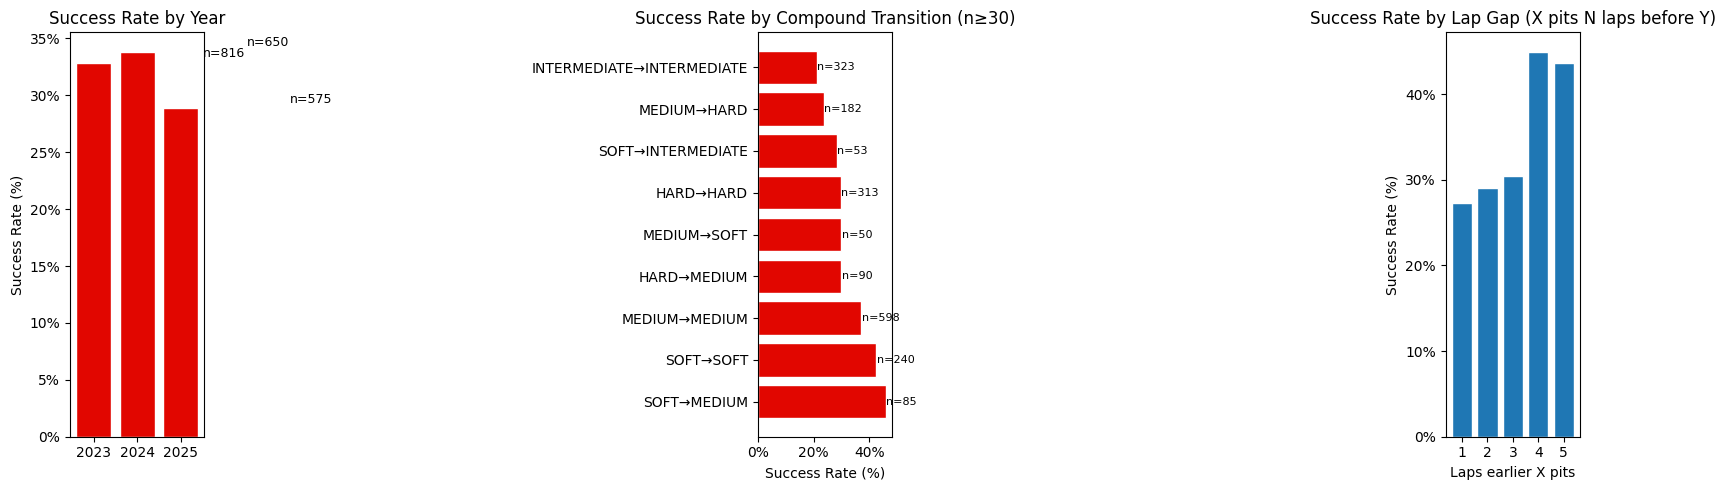

Saved: n16_eda_01_overview.png


In [9]:
df["compound_transition"] = df["Compound_X"] + "→" + df["Compound_Y"]
plot_eda_overview(df)

**Key findings by dimension:**

**Year** — Consistent success rate across seasons (~32–34%), with 2025 slightly lower (~29%).
No major temporal drift; year is unlikely to be a strong feature.

**Compound transition** — SOFT→MEDIUM has the highest success rate, followed by SOFT→SOFT.
INTERMEDIATE→INTERMEDIATE (wet races) also high but confounded by safety car dynamics.
Same-compound transitions dominate the dataset (MEDIUM→MEDIUM, HARD→HARD, SOFT→SOFT).

**Lap gap** — Clear monotonic trend: the earlier X pits relative to Y, the higher the success rate.
Pitting 4–5 laps earlier yields ~45% success vs ~27% for 1 lap earlier.
**Lap_gap is a strong feature candidate.**

#### 1.2 Per Circuit Analysis

In [10]:
def plot_success_by_circuit(df):
    overall_mean = df["undercut_success"].mean()
    sr = (
        df.groupby("GP_Name")["undercut_success"]
        .agg(["mean", "count"])
        .query("count >= 20")
        .sort_values("mean", ascending=False)
        .reset_index()
    )
    colors = ["#e10600" if v > overall_mean else "#555555" for v in sr["mean"]]
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(sr["GP_Name"], sr["mean"] * 100, color=colors, edgecolor="white")
    ax.axvline(overall_mean * 100, color="orange", linestyle="--",
               label=f"Overall mean ({overall_mean:.1%})")
    ax.set_xlabel("Undercut Success Rate (%)")
    ax.set_title("Undercut Success Rate by Circuit (n≥20, 2023–2025)")
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter("%.0f%%"))
    for _, row in sr.iterrows():
        idx = list(sr["GP_Name"]).index(row["GP_Name"])
        ax.text(row["mean"] * 100 + 0.2, idx, f'n={int(row["count"])}', va="center", fontsize=8)
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUTS / "n16_eda_02_by_circuit.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved: n16_eda_02_by_circuit.png")

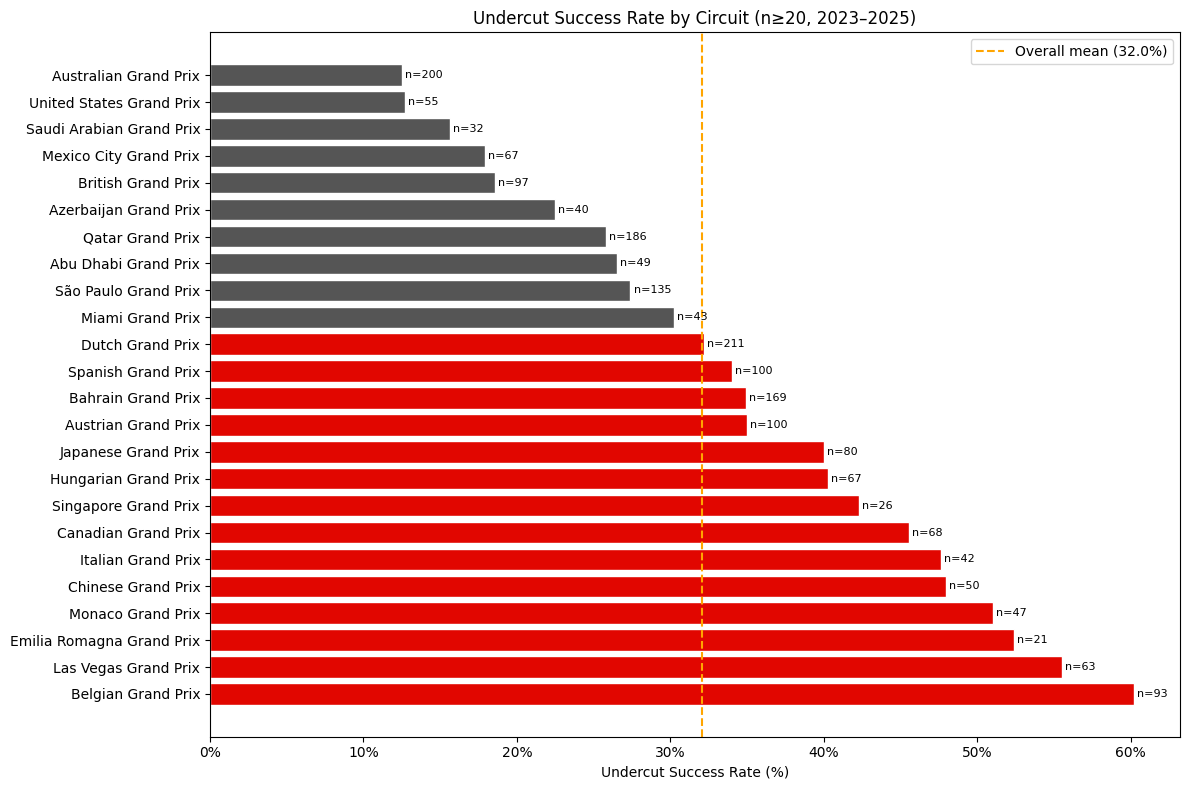

Saved: n16_eda_02_by_circuit.png


In [11]:
plot_success_by_circuit(df)

**Circuit** — High variance: Belgian GP ~62% vs Australian GP ~13%.
Circuit identity encodes track layout (long pit lanes, overtaking difficulty, compound strategy).
`circuit_undercut_rate` will be computed as a feature in Step 2.

#### 1.3 Distributions

In [12]:
def _add_hist_by_outcome(ax, df, col, bins, title, xlabel):
    for label, grp in df.groupby("undercut_success"):
        ax.hist(grp[col].dropna(), bins=bins, alpha=0.6,
                label="Success" if label else "Failure", density=True)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.legend()

def _add_success_rate_bar(ax, df, col, title, xlabel):
    sr = df.groupby(col)["undercut_success"].agg(["mean", "count"]).reset_index()
    ax.bar(sr[col].astype(str), sr["mean"] * 100, color="#e10600", edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Success Rate (%)")
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.0f%%"))

def plot_distributions(df):
    df = df.copy()
    df["pos_gap"] = df["pos_Y_before"] - df["pos_X_before"]
    df["tyre_life_diff"] = df["TyreLife_X"] - df["TyreLife_Y"]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    _add_hist_by_outcome(axes[0, 0], df, "pos_gap", bins=range(-3, 4),
                         title="Position Gap Distribution", xlabel="pos_Y_before − pos_X_before")
    _add_hist_by_outcome(axes[0, 1], df, "tyre_life_diff", bins=20,
                         title="Tyre Life Diff (X − Y)", xlabel="TyreLife_X − TyreLife_Y (laps)")
    _add_hist_by_outcome(axes[1, 0], df, "pit_delta_X", bins=30,
                         title="Pit Delta X Distribution", xlabel="pit_delta_X (s)")
    _add_success_rate_bar(axes[1, 1], df, "pos_gap",
                          title="Success Rate by Position Gap", xlabel="pos_Y_before − pos_X_before")

    plt.tight_layout()
    plt.savefig(OUTPUTS / "n16_eda_03_distributions.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved: n16_eda_03_distributions.png")

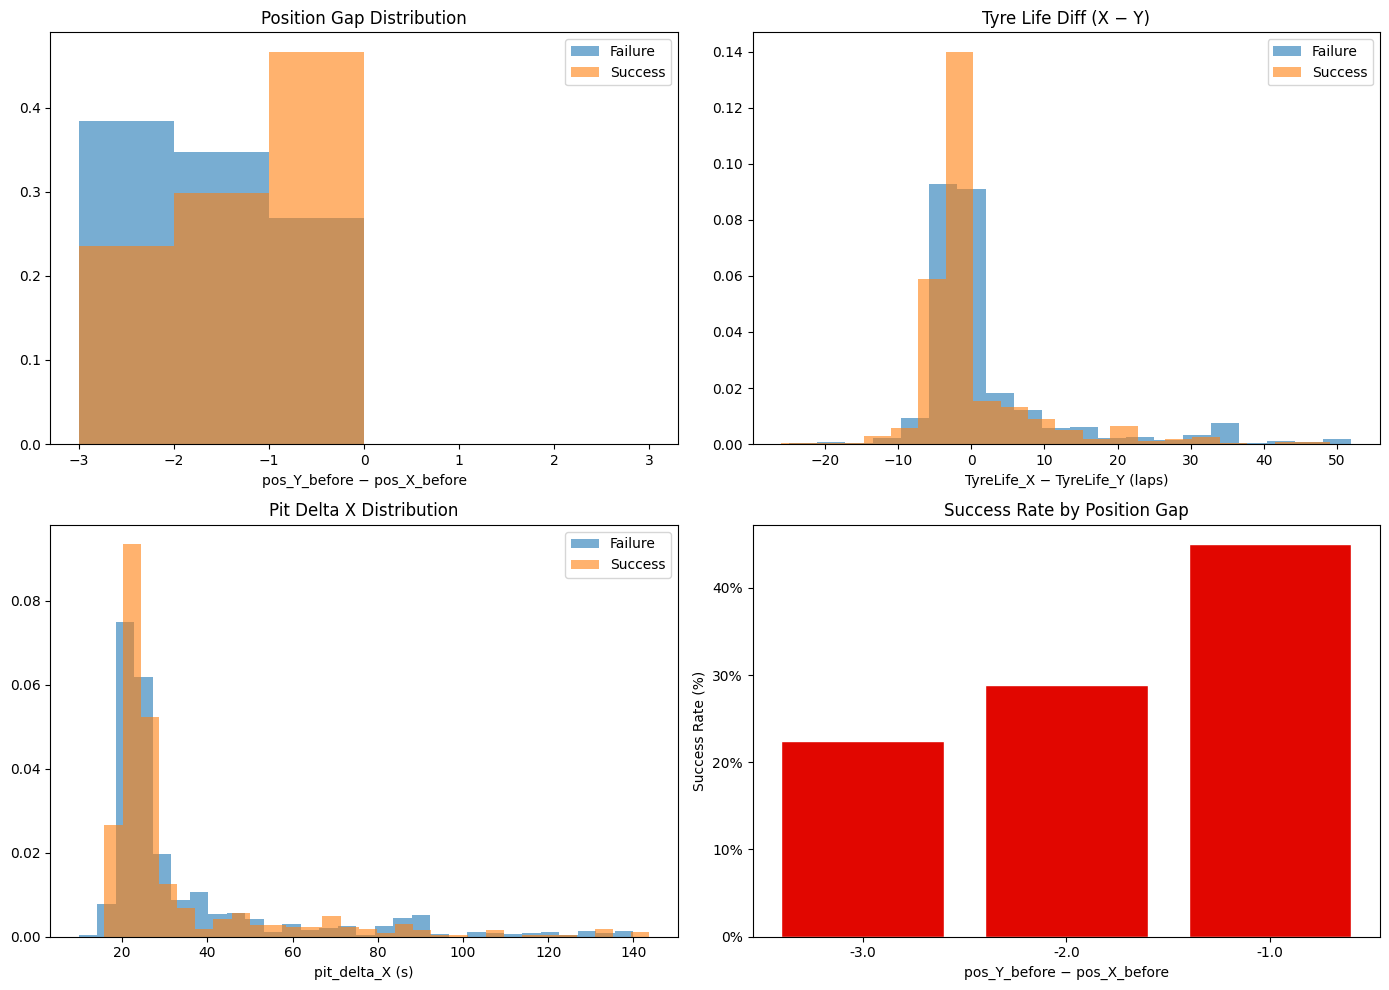

Saved: n16_eda_03_distributions.png


In [13]:
plot_distributions(df)

**Position gap** — Strongest raw signal: when X is just 1 position behind Y (pos_gap = −1),
success is ~45%. Three positions back drops to ~23%.
**pos_gap / pos_X_before are strong feature candidates.**

**Tyre life diff** — Counterintuitive: successful undercuts happen when both drivers have
*similar* tyre ages (mean diff = 0.15 laps), while failures occur when X is already on older
tyres than Y (mean diff = 2.0 laps). When X is desperate to pit (very old tyres), the undercut
rarely works — Y responds too quickly or the pace gain isn't enough.

**Pit delta** — Faster pit stops correlate weakly with success (mean 32.4s vs 34.6s for failures),
but the 14% missingness limits its direct use.

#### 1.4 Summary Stats

In [14]:
def eda_summary(df):
    df = df.copy()
    df["tyre_life_diff"] = df["TyreLife_X"] - df["TyreLife_Y"]
    print("=== Key EDA Takeaways ===")
    print(f"\nTotal pairs: {len(df):,}")
    print(f"Successful undercuts: {df['undercut_success'].sum():,} ({df['undercut_success'].mean():.1%})")
    print(f"Years covered: {sorted(df['Year'].unique())}")
    print(f"Circuits covered: {df['GP_Name'].nunique()}")
    print(f"\nMean tyre life diff (success vs fail):")
    print(df.groupby("undercut_success")["tyre_life_diff"].mean())
    print(f"\nMean pit_delta_X (success vs fail):")
    print(df.groupby("undercut_success")["pit_delta_X"].mean())
    print(f"\nCompound transition counts (top 10):")
    print(df["compound_transition"].value_counts().head(10))

In [15]:
eda_summary(df)

=== Key EDA Takeaways ===

Total pairs: 2,041
Successful undercuts: 654 (32.0%)
Years covered: [2023, 2024, 2025]
Circuits covered: 24

Mean tyre life diff (success vs fail):
undercut_success
0    2.016618
1    0.151840
Name: tyre_life_diff, dtype: float64

Mean pit_delta_X (success vs fail):
undercut_success
0    34.558289
1    32.421872
Name: pit_delta_X, dtype: float64

Compound transition counts (top 10):
compound_transition
MEDIUM→MEDIUM                598
INTERMEDIATE→INTERMEDIATE    323
HARD→HARD                    313
SOFT→SOFT                    240
MEDIUM→HARD                  182
HARD→MEDIUM                   90
SOFT→MEDIUM                   85
SOFT→INTERMEDIATE             53
MEDIUM→SOFT                   50
HARD→SOFT                     24
Name: count, dtype: int64


**Top raw predictors identified for Step 2:**
`pos_gap`, `Lap_gap`, `tyre_life_diff`, `compound_transition`, `circuit_undercut_rate`

---

## Step 1B: Labeling Quality Checks

Before moving to feature engineering, we need to validate that the labeled dataset actually represents real undercut attempts. The labeling logic in Step 0 uses simple heuristics (X pits before Y within 5 laps, X was behind Y) that can generate noise in three ways:

1. **Multiple pairs per pit stop** — if X pits and several rivals pit in the same window, one real tactical decision generates many dataset rows with shared context. High multiplicity inflates the dataset and introduces correlated samples.

2. **Safety Car / VSC contamination** — if a SC or VSC is deployed between X's and Y's pit laps, the position change 3 laps after Y's outlap reflects SC timing luck, not undercut effectiveness. These pairs should be excluded.

3. **Teammate pit stacks** — `Team_X == Team_Y` pairs are coordinated stops by the same team, not tactical undercut attempts against a rival. They should be filtered regardless of position gap.

The three checks below quantify each issue. The `max_pos_gap=3` setting is also inspected manually to decide whether it needs tightening.

In [16]:
def check_pairs_per_pitstop(df):
    pairs_per_pit = df.groupby(["Year", "GP_Name", "Driver_X", "Lap_X_pits"]).size()
    print("Pairs generated per pit stop of X:")
    print(pairs_per_pit.value_counts().sort_index())
    print(f"\nMean pairs per pit stop: {pairs_per_pit.mean():.2f}")
    print(f"Max pairs per pit stop: {pairs_per_pit.max()}")

check_pairs_per_pitstop(df)


Pairs generated per pit stop of X:
1    563
2    319
3    178
4     16
5      7
6     23
7      5
8      2
9      2
Name: count, dtype: int64

Mean pairs per pit stop: 1.83
Max pairs per pit stop: 9


In [17]:
def check_sc_contamination(df):
    sc_count = df["has_sc"].sum()
    total = len(df)
    print(f"Pairs with SC/VSC between X and Y pit laps: {sc_count}/{total} ({sc_count/total:.1%})")

check_sc_contamination(df)

Pairs with SC/VSC between X and Y pit laps: 696/2041 (34.1%)


In [18]:
def manual_check_gp(df, year=2023, gp="Bahrain Grand Prix", n=20):
    subset = df[(df["Year"] == year) & (df["GP_Name"] == gp)].copy()
    cols = ["Driver_X", "Driver_Y", "Lap_X_pits", "Lap_Y_pits", "Lap_gap",
            "pos_X_before", "pos_Y_before", "TyreLife_X", "TyreLife_Y",
            "Compound_X", "Compound_Y", "undercut_success"]
    print(f"{year} {gp} — {len(subset)} pairs")
    print(subset[cols].head(n).to_string(index=False))

manual_check_gp(df)


2023 Bahrain Grand Prix — 71 pairs
Driver_X Driver_Y  Lap_X_pits  Lap_Y_pits  Lap_gap  pos_X_before  pos_Y_before  TyreLife_X  TyreLife_Y Compound_X Compound_Y  undercut_success
     GAS      DEV           9          11        2          19.0          18.0         9.0        11.0       SOFT       SOFT                 1
     GAS      ZHO           9          12        3          19.0          17.0         9.0        12.0       SOFT       SOFT                 1
     GAS      TSU          25          26        1          12.0          11.0        16.0        16.0       HARD       HARD                 1
     GAS      ALB          25          26        1          12.0          10.0        16.0        15.0       HARD       SOFT                 0
     GAS      BOT          25          29        4          12.0           9.0        16.0        18.0       HARD       HARD                 0
     PER      VER          34          36        2           2.0           1.0        19.0        22.0     

### Step 1B Results

**Check 1 — Pairs per pit stop (mean 1.83, max 9)**

Acceptable on average — the majority of pit stops (563) generate a single pair. The long tail (pit stops generating 6–9 pairs) is explained by SC laps where many drivers pit simultaneously. Once SC pairs are removed in the fix step, the multiplicity problem largely disappears on its own.

**Check 2 — SC/VSC contamination: 34.1% (696/2,041 pairs)**

The most critical finding. Over one third of labeled pairs have a safety car or virtual safety car between X's and Y's pit laps. In those cases the position outcome reflects SC timing luck, not undercut effectiveness. These pairs must be removed.

**Check 3 — Manual inspection (Bahrain 2023)**

- **Teammate pairs confirmed**: `PER→VER` (lap 34→36) is a coordinated team pit stack, not an undercut. Filtered via `Team_X != Team_Y`.
- **`max_pos_gap=3` kept**: pairs like `LEC→VER` (P3 vs P1) are present but represent a minority of the dataset. Reducing to 2 would lose too many genuine borderline cases. The position gap is captured as a feature (`pos_gap`) so the model can learn its effect directly.

**Fixes applied:**

| Fix | Change | Removed |
|---|---|---|
| Teammate filter | `Team_X != Team_Y` | 241 pairs |
| SC/VSC filter | `has_sc == False` | 627 pairs |

**Final dataset: 1,173 pairs — success rate 37.3% (438 success / 735 fail, ratio ≈ 1:1.7)**

The success rate increase from 32% → 37.3% after SC removal is expected: SC pairs had inflated success rates since pitting before the SC deployment almost always results in a position gain regardless of undercut quality.

In [19]:
# ── Step 1B · Labeling fixes ─────────────────────────────────────────────────

def apply_labeling_fixes(df):
    n0 = len(df)
    print(f"Starting dataset: {n0} pairs | success rate: {df['undercut_success'].mean():.1%}")

    # Fix 1 — Remove teammate pairs (pit stacks ≠ undercut attempts)
    df = df[df["Team_X"] != df["Team_Y"]].copy()
    n1 = len(df)
    print(f"After teammate filter:   {n1} pairs ({n0 - n1} removed)")

    # Fix 2 — Remove SC/VSC contaminated pairs (has_sc captured during labeling)
    df = df[~df["has_sc"]].copy()
    n2 = len(df)
    print(f"After SC/VSC filter:     {n2} pairs ({n1 - n2} removed)")

    print(f"\nFinal dataset: {n2} pairs | success rate: {df['undercut_success'].mean():.1%}")
    print(f"Total removed: {n0 - n2} ({(n0 - n2) / n0:.1%})")
    print(f"\nTarget distribution:\n{df['undercut_success'].value_counts()}")
    return df


df_clean = apply_labeling_fixes(df)

Starting dataset: 2041 pairs | success rate: 32.0%
After teammate filter:   1800 pairs (241 removed)
After SC/VSC filter:     1173 pairs (627 removed)

Final dataset: 1173 pairs | success rate: 37.3%
Total removed: 868 (42.5%)

Target distribution:
undercut_success
0    735
1    438
Name: count, dtype: int64
